# Introduction to decode_plex Model

The `decode_plex` model is a computational framework designed to reconstruct high-density multi-channel Single Molecule Localization Microscopy (SMLM) data. It builds upon the principles of the DECODE model, which leverages deep learning to achieve high-accuracy localization and reconstruction of densely packed fluorophores in SMLM datasets.


In [34]:
from pathlib import Path
from typing import Sequence

import math
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from tqdm import tqdm

path = "../"
path = Path(path).expanduser()
import sys
sys.path.insert(0, str(path))

# DECODE - Training

This notebook highlights how to generate a training parameter file and train a DECODE model for fitting experimental data.

The DECODE model is trained on simulated data. This requires a calibration spline PSF model (acquired by SMAP or uiPSF model), and a parameter file that contains camera settings and other hyper parameters to set up the simulation process.

If you plan to use DECODE regularly you should take a look at the generated parameter file at the end of this notebook
and will recognise that it just holds a couple of parameters and paths. You will want to adjust these to your data by creating or modifying the .yaml file directly.
After that you can start the training directly (see the last section of this notebook).

## Set parameters
Set device for training. We **do not recommend training on CPU** since this will be quite slow. If you train on CPU though, you may want to change the number of threads if you have a big machine (see below).

In [ ]:
device = 'cuda:0'  # or 'cpu'
device_ix = 0  # possibly change device index (only for cuda)
threads = 4  #  number of threads, useful for CPU heavy computation. Change if you know what you are doing.
worker = 4  # number of workers for data loading. Change only if you know what you are doing.

torch.set_num_threads(threads)  # set num threads

if device != 'cpu':
    if (not torch.cuda.is_available()):
        raise ValueError("You have selected a non CPU device, but CUDA is not available."
                         "Refer to CPU version or check your installation.")

## PSF calibration

The PSF can be obtained through Beads calibration or by fitting using uiPSF. You can find more details about uiPSF in [Liu et al., Nature Methods (2023)](https://doi.org/10.1038/s41592-024-02282-x) and the SMAP user guide (section 5.4) or the publication [Li et al., Nature Methods (2018)](https://doi.org/10.1038/nmeth.4661).


## Simulation Parameters
To set the simulation parameters we load the default config file and go through the settings

In [36]:
import os
import numpy as np
import matplotlib.pyplot as plt
import hydra
import omegaconf
import sys
from omegaconf import DictConfig, OmegaConf

import decode 
import decode.neuralfitter.inference.functional as infer_func
from decode.utils import param_auto
from decode.neuralfitter.train import setup_cfg
from decode.io import psf
from decode import io


In [37]:
def load_and_process_config(config_name: str):
    if not hydra.core.global_hydra.GlobalHydra.instance().is_initialized():
        hydra.initialize(config_path="../config/", job_name="notebook")
    
    cfg = hydra.compose(config_name=config_name)

    auto_cfg = param_auto.AutoConfig(
        fill=False,
        fill_test=False,
        auto_scale=False,
        return_type=DictConfig,
        ref={},
    )

    cfg_dict = OmegaConf.to_container(cfg, resolve=True)

    # Parse the configuration using auto_cfg
    cfg = auto_cfg.parse(cfg_dict)

    # Convert back to OmegaConf DictConfig if needed
    # cfg = OmegaConf.create(cfg)
    
    return cfg


# # cfg["Simulation"]["emitter_avg"] = 17
# # cfg["Trainer"]["frame_window"] = 1
# # cfg["Simulation"]["samples"] = 3000

The camera parameters need to be adjusted according to the device used. Here we used an EMCCD camera, for a sCMOS device you must set the em_gain to None.

In [38]:
cfg = load_and_process_config("base_param.yaml")
for i in range(2):
    # cfg["Camera"][i]["specs"] |= {"flip": {"gain": None, "channel": None}}
    cfg["Camera"][i]["specs"]["baseline"] = 398.6
    cfg["Camera"][i]["specs"]["e_per_adu"] = 5
    cfg["Camera"][i]["specs"]["em_gain"] = 100
    cfg["Camera"][i]["specs"]["px_size"] = [127, 117]
    cfg["Camera"][i]["specs"]["qe"] = 1.
    cfg["Camera"][i]["specs"]["read_sigma"] = 74.4
    cfg["Camera"][i]["specs"]["spur_noise"] = 0.0

### SMAP PSF:
for i in range(2):
   cfg["Camera"][i]["specs"].merge_with({"flip": {"gain": None, "channel": -2}})

# import json
# camera_cfg_list = OmegaConf.to_container(cfg["Simulation"]["bg"], resolve=True)
# print(json.dumps(camera_cfg_list, indent=2))

2026-04-26 23:16:03 [info     ] Running experimental function `_auto_channel_maps` tested=False


The simulation parameters should be set so that the resulting simulated frames resemble real frames as closely as possible.
You can use SMAP to infer these parameters by performing inference with an iterative approach on a couple of frames:

1. Use the bead calibration to fit your SMLM data.
2. Use the plugin: *DECODE\_training\_estimates* to estimate the photo-physical parameters of the experiment and to save them into a parameter file. Consult the information of the plugin (accessible via the Info button) for further information.

However it is also possible to find reasonable values by hand which we do now.

In [39]:
cfg["Simulation"]["bg"] = [{"uniform": [0, 30]}, {"uniform": [50, 200]}]
cfg["Simulation"]["Photon"]["distribution"]["Uniform"]["low"] = [200, 400]    # photon range to sample from.
cfg["Simulation"]["Photon"]["distribution"]["Uniform"]["high"] = [10000, 100000]

cfg["Simulation"]["emitter_extent"]["z"]  = [-600, 600] # Volume in which emitters are sampled. x,y values should not be changed. z-range (in nm) should be adjusted according to the PSF
cfg["Simulation"]["emitter_avg"] = 40  # Average number of emitters per frame
cfg["Simulation"]["lifetime_avg"] = 1. # Average lifetime of each emitter in frames. A value between 1 and 2 works for most experiments

cfg["Trainer"]["frame_window"] = 1 # only for test here

auto_cfg = param_auto.AutoConfig(
        fill=False,
        fill_test=True,
        auto_scale=True,
        return_type=DictConfig,
        ref={},
    )
cfg = auto_cfg.parse(cfg)

# import json
# camera_cfg_list = OmegaConf.to_container(cfg["Simulation"]["bg"], resolve=True)
# print(json.dumps(camera_cfg_list, indent=2))

2026-04-26 23:16:04 [info     ] Running experimental function `_auto_channel_maps` tested=False


Lastly we provide the path to the calibration file, and to the output destination.
There are more parameters (you can just execute param in a cell to look at them) that you should not need to change.
You might have to reduce the batch size (param.HyperParameter.batch_size) if you run out of memory.

In [ ]:
base_dir = Path().resolve()

path_spline = (base_dir / "../calibration/Fig2b-psfmodel_zernike_vector_multi_IMM.h5").resolve()
path_trafo = (base_dir / "../calibration/Fig2b-psfmodel_zernike_vector_multi_IMM.h5" ).resolve()

cfg["Paths"]["base"] = str((base_dir / "../").resolve())
cfg["Paths"]["calibration"] = str(path_spline)
cfg["Paths"]["trafo"] = str(path_trafo)
cfg["Paths"]["logging"] = str((base_dir / "../log").resolve())
cfg["Paths"]["experiment"] = str((base_dir / "../outputs/").resolve())


In dual-color SMLM data, there is often a shift between different channels. During the training process, it is necessary to specify this shift. Fortunately, uiPSF automatically calculates the xy-shift, and we can read this parameter directly from the uiPSF file. Alternatively, we also support manually setting this parameter if needed.


In [41]:
path_trafo = cfg["Paths"]["trafo"]
path = path_trafo if isinstance(path_trafo, Path) else Path(path_trafo)

from decode.io.psf import load_h5

if path.suffix == ".h5": # if the trafo file is a h5 file, we will extract the flip and offset from the file. Otherwise, we will use the default values.
    for i in range(2):
        cfg["Camera"][i]["specs"].merge_with({"flip": {"gain": None, "channel": -2}})
    f, p = load_h5(path)
    offset = (f.res.xyshift[:,[1,0]]-0.5).astype(int).tolist()
    offset[1][1] = -offset[1][1]        
    for s in ["Simulation", "Test"]:
        cfg[s]["Transformation"]["Pos"]["glob"]["offset"] = {"x": offset[0], "y": offset[1], "z": [0, 0]}
        cfg[s]["Transformation"]["Pos"]["glob"].merge_with({"flip": None})
else: # You could use the ./notebook/trafo_debug.ipynb to find the optimal offset values.
    cfg["Simulation"]["Transformation"]["Pos"]["glob"]["flip"] = {"dim": 0, "channel":1, "frame_size":512}
    cfg["Test"]["Transformation"]["Pos"]["glob"]["flip"] = {"dim": 0, "channel":1, "frame_size":512}
    cfg["Simulation"]["Transformation"]["Pos"]["glob"]["offset"] = {"x": [0, -35], "y": [0, -1],"z":[0, 0]}
    cfg["Test"]["Transformation"]["Pos"]["glob"]["offset"] = {"x": [0, -29], "y": [0, -1],"z":[0, 0]}



Now we can set up our simulator and the camera model.

In [42]:
sampler = setup_cfg.setup_sampler(cfg, cfg["Simulation"])

2026-04-26 23:16:04 [info     ] Loading transformation.        path=/home/shahao/projects/DECODE-Plex/calibration/240802_NC_BeadCal_DualColor/psfmodel_zernike_vector_multi_IMM_flip_swap.h5 reference=trafo_inv_raw
2026-04-26 23:16:04 [info     ] Running experimental function `load_xyz_trafo` tested=True


2026-04-26 23:16:04 [info     ] Offsets as specified in .h5 file.
2026-04-26 23:16:04 [debug    ] Final transformation.          trafo=XYZCompositTransformation([
    XYZShiftTransformation(tensor([-128., -256.,    0.], device='cuda:0'), cuda:0),
    XYZTransformationGeneric(<function _coord_permute_smap at 0x7bc32acf9e10>, None, cuda:0, True),
    XYZTransformationMatrix(tensor([[[ 1.0000e+00,  0.0000e+00,  0.0000e+00],
         [ 0.0000e+00,  1.0000e+00,  0.0000e+00],
         [ 0.0000e+00,  0.0000e+00,  1.0000e+00]],

        [[ 9.9977e-01, -3.7606e-02, -7.8589e-18],
         [ 3.7535e-02,  1.0010e+00,  5.5511e-17],
         [-2.2863e+01,  2.4991e+00,  1.0000e+00]]])),
    XYZTransformationGeneric(<function _coord_permute_smap at 0x7bc32acf9e10>, None, cuda:0, True),
    XYZShiftTransformation(tensor([128., 256.,  -0.], device='cuda:0'), cuda:0),
    XYZChanneledTransformation(XYZShiftTransformation(tensor([ 0, 23,  0], device='cuda:0'), cuda:0), 1)
])
2026-04-26 23:16:04 [info     

Let us sample a set frames, and also load our data:

In [ ]:
sampler.sample()
em_ref = sampler.em
sim_frames = sampler.frame


from decode.io.frames import TiffTensor 

path_frames = "../data/Fig2b-240802_NC_ER_MT_TritonX100_2percent_2/240802_NC_ER_MT_TritonX100_2percent_2_MMStack_Default_1.ome.tif"
path_frames = Path(path_frames).expanduser()

data_frames = decode.io.frames.load_tif(path_frames, auto_ome=False, memmap=True)
frame_size = list(data_frames.size())
frame_crop = [math.floor(frame_size[-2] / 8) * 8, math.floor(frame_size[-1] / 8) * 8]
# max x out at 256
frame_crop[0] = min(frame_crop[0], 256) 

pre = setup_cfg.setup_frame_pre_multi_roi(
                        cfg, cfg["Camera"][0]["specs"], "cpu", "Test", frame_crop
                    )

if isinstance(data_frames, TiffTensor):
    data_frames = torch.stack([data_frames[i] for i in range(len(data_frames))])

data_frames = pre.forward(data_frames)

2026-04-26 23:16:41 [warning  ] Overwriting/Inferring code from phot instead of em.code.


[26-04-2026 23:16:43] [tifffile] [WARNING] <tifffile.TiffTag 270 @164959> coercing invalid ASCII to bytes, due to UnicodeDecodeError('charmap', b'\xcc\x02\x7f\x03\xff\x01\xae\x02E\x02\xad\x02\xec\x02\x81\x020\x03+\x03\xea\x02 \x03\xb9\x02@\x0


2026-04-26 23:16:45 [info     ] Setting up frame pre-processing in multi-roi mode, on a single camera.
2026-04-26 23:16:45 [info     ] Offsets as specified in .h5 file. offset=[0, 23]


In [44]:
print(f'Data shapes, simulation: {np.array(sim_frames).squeeze().shape}, real data: {np.array(data_frames).shape}')
print(f'Average value in channel 0, simulation: {sim_frames[0].mean().round()}, real data: {data_frames[0].mean().round()}')
print(f'Average value in channel 1, simulation: {sim_frames[1].mean().round()}, real data: {data_frames[1].mean().round()}')

Data shapes, simulation: (2, 10000, 40, 40), real data: (2, 7811, 256, 512)
Average value in channel 0, simulation: 67.0, real data: 13.0
Average value in channel 1, simulation: 547.0, real data: 84.0


By comparing random frames (chosing a dense region of the real data) we can convince ourselves that the distributions are somewhat similar.
If you observe large differences for your dataset, you probably have to adjust param.Simulation.bg_uniform and param.Simulation.intensity_mu_sig

torch.Size([2, 10000, 40, 40])


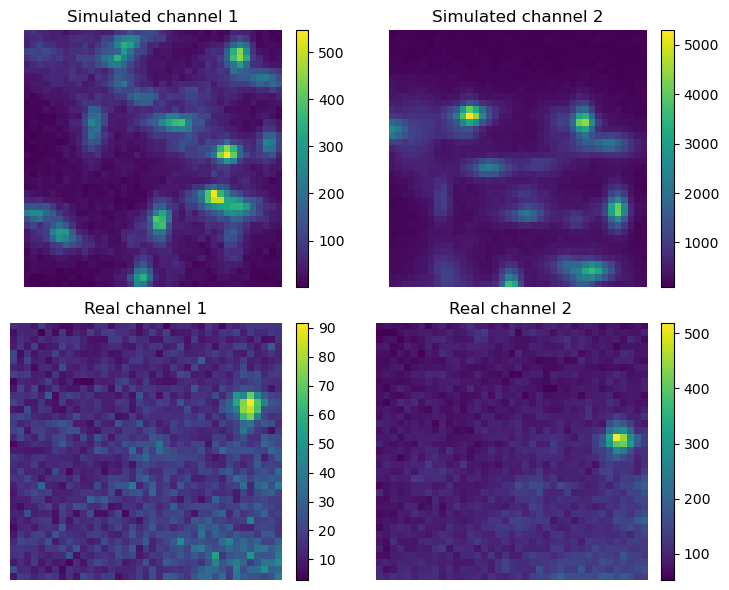

In [57]:
frames_ = torch.stack(sim_frames, dim=0).squeeze()
data_frames_ = torch.stack(data_frames, dim=0)
print(frames_.shape)

idx = np.random.randint(0, 1000)
fig, axes = plt.subplots(2, 2, figsize=(8, 6))
for i in range(2):
    axes[0,i].imshow(frames_[i][idx].squeeze())
    axes[0,i].axis("off")
    axes[0,i].set_title(f"Simulated channel {i+1}")

    axes[1,i].imshow(data_frames_[i][idx][128:165,156:195].squeeze())
    axes[1,i].axis("off")
    axes[1,i].set_title(f"Real channel {i+1}")
    
    cbar = fig.colorbar(axes[0, i].images[0], ax=axes[0, i], orientation='vertical', fraction=0.046, pad=0.04)
    cbar = fig.colorbar(axes[1, i].images[0], ax=axes[1, i], orientation='vertical', fraction=0.046, pad=0.04)
plt.tight_layout()

**Note:** If your available (i.e. free) GPU memory is lower than 6GB you will likely run into memory errors. Check your total GPU memory on the set device by running the cell below.
To avoid this you can lower the batch_size to 32 to 16. However you should have at least a 4GB GPU available. You might be able to run training on a smaller GPU using very small batch sizes but this will negatively impact performance.

**Note:** If other processes or a screen attached to the GPU you want to train on consumes GPU resources, the free GPU memory might be significantly lower than the total GPU memory size.

In [ ]:
if device != 'cpu':
    mem_gb = torch.cuda.get_device_properties(device).total_memory / 1e9
    print(f"Your approximate total GPU memory size on the set device {device} is {mem_gb:.2f} GB.")


cfg["Trainer"]["batch_size"] = 16
cfg["Trainer"]["frame_window"] = 3
cfg["Trainer"]["max_epochs"] = 1000


cfg["Meta"]["tag"] = "experiments"
cfg["Meta"]["version"] = "Fig2a"

cfg["hydra"] = {"job": {"chdir": True}, 
                "run":{"dir":"${Paths.experiment}/${Meta.tag}/${Meta.version}/${now:%Y-%m-%d_%H-%M-%S-%f}"}}


Your approximate total GPU memory size on the set device cuda:3 is 25.30 GB.


Once you are happy with you settings you can write the parameters to a file (or edit the param_friendly.yaml directly)

In [47]:
param_out_dir = "../config/" # or an alternative path
param_out_name = "notebook_example_IMM_filp_swap.yaml"
omegaconf.OmegaConf.save(cfg, param_out_dir+param_out_name)


## Start Training

After configuring the training parameters, you can start training using:
```bash
conda activate decode_plex
cd DECODE-Plex/
python -m cli.train --config-name notebook_example
```

The model is automatically saved after each epoch. Training can be stopped at any time.

### Checkpoint Initialization and Warm Start

Training can be initialized in two different ways:

- **Warm start**: initialize the network from a pre-trained model to accelerate convergence  (Fig S7)

  → set `cfg["Paths"]["checkpoint_warmstart"]`

- **Resume training**: continue a previous training run from a saved checkpoint  

  → set `cfg["Paths"]["checkpoint_init"]`

These two options serve different purposes: warm start is typically used to adapt a model to a new PSF or data distribution, while checkpoint initialization restores the exact training state.

### Monitoring Training

Training progress can be monitored using TensorBoard:
```bash
tensorboard --port=6006 --logdir=./log
```

Then open in your browser: http://localhost:6006

TensorBoard provides various evaluation metrics and example reconstructions based on simulated data. These are useful for assessing convergence, but final performance should always be evaluated on experimental data.

### Provided Configurations and Calibration Data

We provide all configuration files and calibrated PSF models corresponding to the results and figures in the paper. To reproduce specific experiments, please update the file paths in the corresponding `param_run` configuration files to match your local setup.

In [48]:

# !nohup python -m cli.train --config-name param_run_240802_crlb > log.txt 2>&1 &
# python -m cli.train --config-name notebook_example


For better fitting performance on your own dataset, we recommand that you need to carfully look about such parameters:
- PSF and Trafo path
- bg and phots distributions
- Transformation offset
- emitter_avg numbers in ./config/Simulation/base_multi.yaml or directly change it in this notebook.
